# 02. Baselines

Notebook para documentar el baseline TF-IDF + Logistic Regression.


In [ ]:
## Objetivo del baseline

El propósito de este cuaderno es documentar el rendimiento de un modelo base de clasificación de texto construido mediante una representación TF-IDF y un clasificador Logistic Regression. Este baseline se utiliza como punto de referencia inicial para valorar si el empleo de modelos más avanzados, como los transformadores en español, aporta mejoras reales en la detección de toxicidad.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS_TABLES = BASE_DIR / "outputs" / "tables"
OUTPUTS_FIGURES = BASE_DIR / "outputs" / "figures"
OUTPUTS_METRICS = BASE_DIR / "outputs" / "metrics"

OUTPUTS_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUTS_METRICS.mkdir(parents=True, exist_ok=True)



In [2]:
with open(OUTPUTS_METRICS / "baseline_tfidf_logreg_metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)

summary = pd.DataFrame([
    {"split":"val","accuracy":metrics["val"]["accuracy"],"f1_macro":metrics["val"]["f1_macro"]},
    {"split":"test","accuracy":metrics["test"]["accuracy"],"f1_macro":metrics["test"]["f1_macro"]},
    {"split":"external_validation_detoxis","accuracy":metrics["external_validation_detoxis"]["accuracy"],"f1_macro":metrics["external_validation_detoxis"]["f1_macro"]},
])
summary.to_csv(OUTPUTS_TABLES / "baseline_metrics_summary.csv", index=False, encoding="utf-8-sig")
summary


,split,accuracy,f1_macro
0,val,0.703054,0.691647
1,test,0.711501,0.701256
2,external_validation_detoxis,0.605416,0.580494


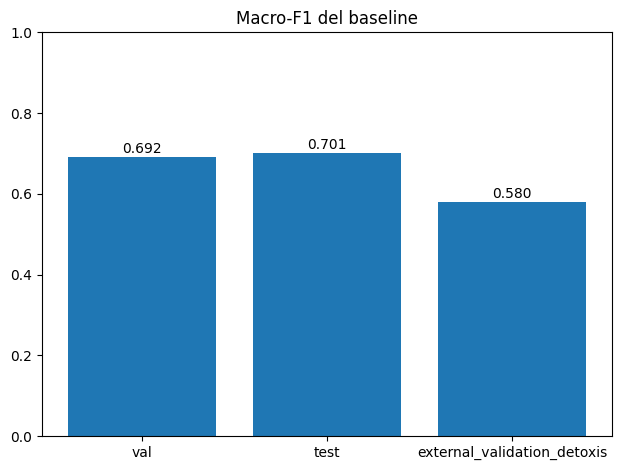

In [3]:
fig, ax = plt.subplots()
ax.bar(summary["split"], summary["f1_macro"])
ax.set_title("Macro-F1 del baseline")
ax.set_ylim(0, 1)
for i, v in enumerate(summary["f1_macro"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
fig.tight_layout()
fig.savefig(OUTPUTS_FIGURES / "baseline_macro_f1.png", dpi=150, bbox_inches="tight")
plt.show()


In [4]:
summary["observacion"] = [
    "Validación interna",
    "Generalización interna",
    "Cambio de dominio"
]
summary


,split,accuracy,f1_macro,observacion
0,val,0.703054,0.691647,Validación interna
1,test,0.711501,0.701256,Generalización interna
2,external_validation_detoxis,0.605416,0.580494,Cambio de dominio


In [ ]:
## Observaciones del baseline

El modelo baseline alcanzó un rendimiento razonable en los conjuntos internos del proyecto. En validación, obtuvo un Macro-F1 de 0.6916, mientras que en el conjunto de prueba alcanzó un Macro-F1 de 0.7013. Estos valores indican que el enfoque clásico basado en TF-IDF y Logistic Regression es capaz de capturar patrones léxicos relevantes para la tarea de clasificación binaria de toxicidad.

Sin embargo, al evaluar el mismo modelo sobre el conjunto de validación externa `DETOXIS`, el Macro-F1 descendió hasta 0.5805. Esta caída sugiere que el modelo presenta limitaciones de generalización cuando se enfrenta a un dominio diferente del empleado en entrenamiento. En otras palabras, el baseline logra un desempeño aceptable sobre los datos internos, pero su robustez disminuye cuando cambia el estilo, el contexto o la naturaleza de los comentarios.

Este comportamiento era esperable en modelos clásicos basados en bolsas de palabras o n-gramas, ya que suelen depender en mayor medida de patrones superficiales del texto y presentan más dificultades para capturar relaciones semánticas complejas o variaciones contextuales.

## Conclusiones del baseline

El baseline constituye una referencia útil y metodológicamente necesaria para el proyecto. Sus resultados muestran que un enfoque clásico puede alcanzar un nivel de rendimiento aceptable en escenarios internos, pero también evidencian limitaciones claras en términos de generalización externa.

Por tanto, el baseline confirma dos aspectos clave: primero, que el problema planteado es abordable con técnicas de clasificación supervisada; y segundo, que existe margen de mejora suficiente como para justificar el uso de modelos basados en transformadores. En este sentido, el baseline cumple adecuadamente su papel como punto de comparación para la siguiente fase experimental.
